# Pseudo label

Pseudo labeling uses the unlabeled test set. I run a trained model to infer labels on the test rows, then train on the real labeled data plus the pseudo-labeled rows. It adds no real targets, but it exposes the model to the test features, which helps it learn relationships that transfer.

The target is a probability and the metric is AUC, so the pseudo-labels are continuous in 0 to 1. I trained with XGBRegressor on objective reg:logistic, which takes soft labels in 0 to 1 and outputs probabilities.

In [1]:
VER = 1

## Load data

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBRegressor

train = pd.read_parquet('data/train_features.parquet')
y_train_true = train['PitNextLap'].astype(int).values
print('Train shape:', train.shape)

Train shape: (439140, 114)


In [3]:
test = pd.read_parquet('data/test_features.parquet')
print('Test shape:', test.shape)

Test shape: (188165, 113)


## Setup

Same 10-fold StratifiedGroupKFold on Race and Year used everywhere else. The fold order has to match 03 so pred_xgb by fold lines up. I pseudo-label on the static features, no per-fold target encodings. The pseudo-labels already carry the target-encoding signal from the stage-1 models.

In [4]:
N_SPLITS = 10
RANDOM_STATE = 42

RAW_NUMERIC = ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position',
               'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
               'RaceProgress', 'Position_Change']
ENGINEERED  = ['stint_progress', 'laps_remaining_frac', 'p_one_stop',
               'pit_window_cdf', 'compound_stint_pit_rate', 'prev_lap_time_delta',
               'laptime_tenths', 'laptime_hundredths', 'laptime_thousandths',
               'tyrelife_is_integer', 'nearest_real_pitnextlap', 'nearest_real_distance',
               'lap_time_pct_in_lap', 'same_compound_drivers_this_lap']
STATIC = RAW_NUMERIC + ENGINEERED + ['Race']

X      = train[STATIC].copy()
X_test = test[STATIC].copy()
X['Race']      = X['Race'].astype('category')
X_test['Race'] = pd.Categorical(X_test['Race'], categories=X['Race'].cat.categories)

groups = train.groupby(['Race', 'Year']).ngroup().values
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

xgb_params = dict(
    n_estimators=2000, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, objective='reg:logistic', eval_metric='auc',
    tree_method='hist', enable_categorical=True,
    random_state=RANDOM_STATE, early_stopping_rounds=50,
)

## Pseudo label with XGB

I pseudo-label the validation and test sets with the stage-1 XGB predictions, then add that data to training. The model sees more feature variety while the real validation rows keep their real labels for scoring. One caveat: the val features go into training with pseudo-labels, so this OOF runs mildly optimistic. The technique still helps on the leaderboard.

In [5]:
oof_xgb  = np.load(f'data/train_oof_xgb_v{VER}.npy')
pred_xgb = np.load(f'data/test_pred_xgb_v{VER}.npy')   # (N_SPLITS, len(test)), per-fold (NOT averaged)

oof_pseudo  = np.zeros(len(train))
pred_pseudo = np.zeros((N_SPLITS, len(test)))

for fold, (tr, va) in enumerate(cv.split(X, y_train_true, groups)):
    X_tr, X_va = X.iloc[tr], X.iloc[va]
    y_tr, y_va = y_train_true[tr], y_train_true[va]

    # Pseudo-label test (this fold's preds) and val (its OOF preds)
    pseudo_test = pred_xgb[fold]
    pseudo_val  = oof_xgb[va]
    X_aug = pd.concat([X_tr, X_test, X_va], axis=0)
    y_aug = np.concatenate([y_tr, pseudo_test, pseudo_val])

    model = XGBRegressor(**xgb_params)
    model.fit(X_aug, y_aug, eval_set=[(X_va, y_va)], verbose=500)
    oof_pseudo[va]    = model.predict(X_va)
    pred_pseudo[fold] = model.predict(X_test)
    print(f'Fold {fold+1} AUC: {roc_auc_score(y_va, oof_pseudo[va]):.5f}  best_iter={model.best_iteration}')

print('-' * 40)
print(f'Pseudo-Label XGB, CV OOF AUC: {roc_auc_score(y_train_true, oof_pseudo):.5f}')
np.save(f'data/train_oof_pseudo_v{VER}.npy', oof_pseudo)
np.save(f'data/test_pred_pseudo_v{VER}.npy', pred_pseudo)

[0]	validation_0-auc:0.91665


[500]	validation_0-auc:0.94516


[1000]	validation_0-auc:0.94610


[1014]	validation_0-auc:0.94609


Fold 1 AUC: 0.94614  best_iter=964


...

[500]	validation_0-auc:0.94949


[1000]	validation_0-auc:0.95013


[1008]	validation_0-auc:0.95014


Fold 10 AUC: 0.95015  best_iter=958
----------------------------------------


Pseudo-Label XGB, CV OOF AUC: 0.92633


## Pseudo label with the ensemble

Now I pseudo-label with the full hill-climb ensemble. That adds knowledge distillation on top of pseudo labeling. The ensemble's behavior gets transferred into a single XGBoost model.

In [6]:
from data.utils import hill_climb_ensemble

def neg_auc(y_true, y_pred):
    return 1.0 - roc_auc_score(y_true, y_pred)

model_names = ['linear', 'xgb', 'lgb', 'cb', 'stack_target', 'stack_feature']
oof_list, test_list, test_full = [], [], []
for k in model_names:
    oof_list.append(np.load(f'data/train_oof_{k}_v{VER}.npy'))
    tp = np.load(f'data/test_pred_{k}_v{VER}.npy')
    test_list.append(tp.mean(0))
    test_full.append(tp)

result = hill_climb_ensemble(
    oofs=oof_list, test_preds=test_list, names=model_names,
    y_true=y_train_true, metric=neg_auc,
    max_number_models=None, tolerance=1e-6, use_negative_weights=False,
)
ensemble_auc = roc_auc_score(y_train_true, result['oof_pred'])
print(f'Hill-climb ensemble OOF AUC: {ensemble_auc:.5f}')

Initial model: cb  score=0.068142


Add model: lgb  alpha=0.3600  score=0.067441


Add model: stack_feature  alpha=0.0100  score=0.067427


Stopping: improvement 0.000e+00 < tolerance

Final ensemble (collapsed):
                    cb  weight=0.633600
                   lgb  weight=0.356400
         stack_feature  weight=0.010000


Final score = 0.067427


Hill-climb ensemble OOF AUC: 0.93257


## Knowledge distillation

Pseudo-labeling the validation and test sets with the ensemble prediction distills the ensemble into one XGBoost model. The soft targets carry more information than hard 0/1 labels. The single model can end up matching or beating the ensemble it learned from.

In [7]:
oof_pseudo_full  = np.zeros(len(train))
pred_pseudo_full = np.zeros((N_SPLITS, len(test)))

for fold, (tr, va) in enumerate(cv.split(X, y_train_true, groups)):
    X_tr, X_va = X.iloc[tr], X.iloc[va]
    y_tr, y_va = y_train_true[tr], y_train_true[va]

    # Ensemble pseudo-labels: weighted blend of each model's fold-test preds and val OOF
    pseudo_test = np.zeros(len(test))
    pseudo_val  = np.zeros(len(va))
    for m, w in zip(result['used_models'], result['weights']):
        pseudo_test += w * test_full[m][fold]
        pseudo_val  += w * oof_list[m][va]

    X_aug = pd.concat([X_tr, X_test, X_va], axis=0)
    y_aug = np.concatenate([y_tr, pseudo_test, pseudo_val])

    model = XGBRegressor(**xgb_params)
    model.fit(X_aug, y_aug, eval_set=[(X_va, y_va)], verbose=500)
    oof_pseudo_full[va]    = model.predict(X_va)
    pred_pseudo_full[fold] = model.predict(X_test)
    print(f'Fold {fold+1} AUC: {roc_auc_score(y_va, oof_pseudo_full[va]):.5f}  best_iter={model.best_iteration}')

print('-' * 40)
print(f'Distilled XGB, CV OOF AUC: {roc_auc_score(y_train_true, oof_pseudo_full):.5f}')
np.save(f'data/train_oof_pseudo_full_v{VER}.npy', oof_pseudo_full)
np.save(f'data/test_pred_pseudo_full_v{VER}.npy', pred_pseudo_full)

[0]	validation_0-auc:0.91153


[500]	validation_0-auc:0.94564


[1000]	validation_0-auc:0.94654


[1323]	validation_0-auc:0.94675


Fold 1 AUC: 0.94680  best_iter=1273


...

[500]	validation_0-auc:0.95004


[1000]	validation_0-auc:0.95047


[1096]	validation_0-auc:0.95045


Fold 10 AUC: 0.95049  best_iter=1046
----------------------------------------


Distilled XGB, CV OOF AUC: 0.93301


## Summary

All models plus the hill-climb ensemble, by CV OOF AUC. If distillation worked, pseudo_full should sit near or below the ensemble on AUC-error.

linear         model has 0.87888 OOF AUC
xgb            model has 0.92424 OOF AUC
lgb            model has 0.93033 OOF AUC
cb             model has 0.93186 OOF AUC
stack_target   model has 0.92602 OOF AUC
stack_feature  model has 0.90991 OOF AUC
hill_climb     model has 0.93257 OOF AUC
pseudo         model has 0.92633 OOF AUC
pseudo_full    model has 0.93301 OOF AUC


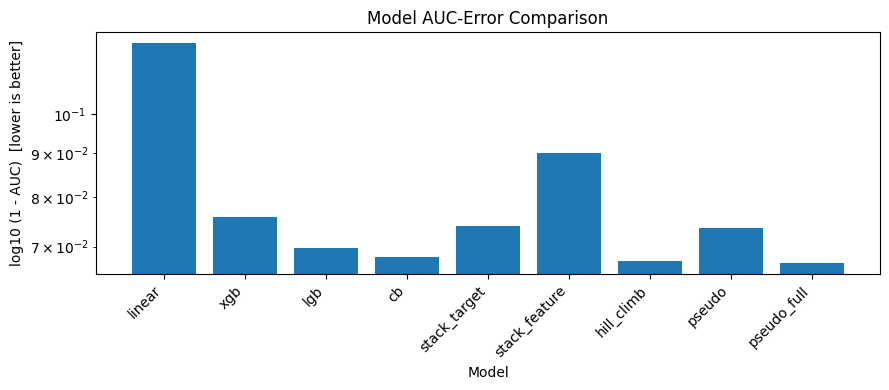

In [8]:
summary_names = ['linear', 'xgb', 'lgb', 'cb', 'stack_target', 'stack_feature', 'pseudo', 'pseudo_full']
aucs = []
for k in summary_names:
    oof = np.load(f'data/train_oof_{k}_v{VER}.npy')
    aucs.append(roc_auc_score(y_train_true, oof))

# insert the hill-climb ensemble for context
summary_names.insert(6, 'hill_climb')
aucs.insert(6, ensemble_auc)

for m, a in zip(summary_names, aucs):
    print(f'{m:14s} model has {a:.5f} OOF AUC')

errs = [1 - a for a in aucs]
plt.figure(figsize=(9, 4))
plt.bar(summary_names, errs)
plt.ylabel('log10 (1 - AUC)  [lower is better]')
plt.xlabel('Model')
plt.title('Model AUC-Error Comparison')
plt.xticks(rotation=45, ha='right')
plt.yscale('log')
plt.tight_layout()
plt.show()

## Write the Kaggle submission

I average the 10 per-fold test predictions from the final model, pseudo_full, the distilled XGB at OOF AUC 0.93301, and write submission_pseudo_full.csv in the Kaggle id,PitNextLap format.

In [9]:
# === Kaggle submission: final model = pseudo_full (distilled XGB), OOF AUC 0.93301 ===
final_pred = np.load(f'data/test_pred_pseudo_full_v{VER}.npy').mean(axis=0)  # average the 10 per-fold test preds

if 'id' in test.columns:
    sub_ids = test['id'].values
else:
    raw_test = pd.read_csv('data/test.csv')
    assert len(raw_test) == len(final_pred), 'row count mismatch - cannot align ids'
    sub_ids = raw_test['id'].values

submission = pd.DataFrame({'id': sub_ids, 'PitNextLap': final_pred})
submission.to_csv('submission_pseudo_full.csv', index=False)
print(f'wrote submission_pseudo_full.csv  rows={len(submission)}  '
      f'pred[min/mean/max]={final_pred.min():.4f}/{final_pred.mean():.4f}/{final_pred.max():.4f}')
submission.head()

wrote submission_pseudo_full.csv  rows=188165  pred[min/mean/max]=0.0001/0.1961/0.9828


,id,PitNextLap
0,439140,0.003423
1,439141,0.004823
2,439142,0.003724
3,439143,0.009201
4,439144,0.755868
